#### Libraries

In [1]:
import numpy as np
import gymnasium as gym
from IPython.display import clear_output
import time
import matplotlib.pyplot as plt

#### Implementation of our own q-algorithm

In [2]:
env = gym.make('Taxi-v3', render_mode='ansi').env
env.np_random = np.random.default_rng(123)
env.action_space.seed(123)
env.observation_space.seed(123)

[123]

In [3]:
# we inicialize our Q matrix to 0s
num_states = env.observation_space.n
num_actions = env.action_space.n
qu = np.zeros([num_states, num_actions])

In [4]:
# defining our parameters
learning_rate = 0.001
discount_factor = 0.99

In [5]:
episodes = 100000
reward_episode = []
alfa = 0.1
initial_epsilon = 1.0 
final_epsilon = 0.1  
epsilon_decay = 0.995
epsilon = initial_epsilon
steps_done = 0
training_reward = []
for i in range(episodes):
    done = False
    state = env.reset()[0]
    sum_reward = 0
    steps_done = 0
    while done==False:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(qu[state])
        
        next_state, reward, done, truncated, info2 = env.step(action)
        sum_reward = sum_reward + reward
        # we use the epsilon greedy decay strategy
        epsilon = max(final_epsilon, initial_epsilon * epsilon_decay**i)
        qu[state,action] = qu[state,action] + learning_rate*(reward + discount_factor*max(qu[next_state,:])-qu[state,action])
        state = next_state
        steps_done = steps_done + 1
        if steps_done == 200:
            break
        
    if i==0:
        reward_episode.append(sum_reward)
    else:
        smoothed_reward = alfa * sum_reward + (1-alfa)* reward_episode[-1]
        reward_episode.append(smoothed_reward)
    training_reward.append(sum_reward)
    average_reward = np.mean(training_reward[-100:])
    if average_reward >= 0:
        print(average_reward)
        print(f"Success at episode: {i}")
        break

0.13
Success at episode: 98471


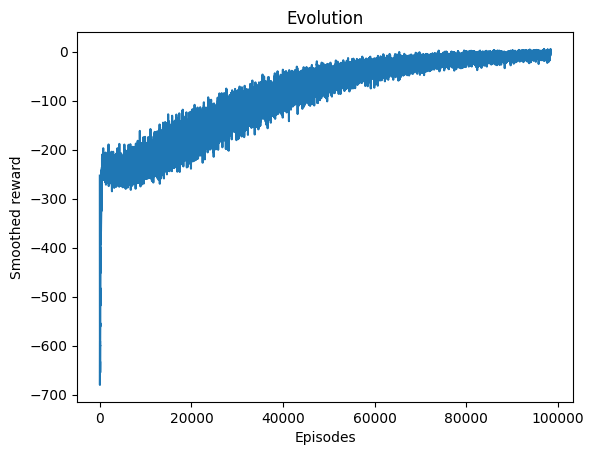

In [7]:
plt.plot(reward_episode)
plt.xlabel('Episodes')
plt.ylabel('Smoothed reward')
plt.title('Evolution')
plt.show()

#### We test it

In [ ]:
env = gym.make('Taxi-v3', render_mode='ansi').env
env.np_random = np.random.default_rng(123)
env.action_space.seed(123)
env.observation_space.seed(123)

[123]

In [ ]:
# we apply pur qu matrix to see if it works well
time.sleep(0.5)
state = env.reset()[0]
print(state)
print(env.render())
done = False
while done==False:
    action = np.argmax(qu[state])
    next_state, reward, done, info, info2 = env.step(action)
    state = next_state
    clear_output(wait=True)
    print(env.render())
    time.sleep(0.5)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



In [ ]:
average_reward = []
for episode in range(100):
    state = env.reset()[0]
    done = False
    sum_reward = 0
    steps = 0
    while done==False:
        action = np.argmax(qu[state])
        next_state, reward, done, truncated, info2 = env.step(action)
        state = next_state
        sum_reward += reward
        steps +=1 
        if steps == 100:
            break
    average_reward.append(sum_reward)
print(np.mean(average_reward))

7.22
